In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as sts
import pandas as pd
import math
import statistics


Часть I

Пункт 1

Смоделировать выборку из п независимых наблюдений над случайной величиной X, 
имеющей нормальный закон распределения с параметрами (a, sigma^2)


In [3]:
a = - 2
sigma = 1
n = 110
q = 0.8
k = 3
print(n)

110


In [3]:
np.random.seed(12)
dist = np.random.normal(size = n, loc = a, scale = sigma)

print(dist)
#plt.plot(dist)

[-1.52701417 -2.68142588 -1.7575605  -3.70073563 -1.24685717 -3.53472134
 -1.99487292 -2.12022767 -2.80698188  0.87181939 -2.59782292 -1.52754301
 -0.90404388 -3.2151688  -0.65764363 -2.12214979 -0.98748452 -2.91386915
 -3.02953021 -0.79020355 -1.4981277  -1.86115382 -1.35923889 -1.47266733
 -3.15436024 -4.21333348 -3.68175651 -3.78809425 -4.21853495 -2.64743078
 -2.52840432 -2.03920917 -1.78502405 -2.3843588  -2.25390408 -1.92674793
 -2.99720384 -2.71385629 -1.96458365 -2.67794537 -2.57188106 -2.10586232
 -0.66416866 -1.68133471 -2.33759525 -2.58526828 -2.11491994  0.24181779
 -5.14741652 -1.46486411 -1.76750956 -1.13238805 -3.14821271  0.11434424
 -0.99905724 -2.051415   -1.8402123  -2.71626359 -1.94947717 -2.14333741
 -1.05642461 -1.64235577 -2.0834492  -1.3221939  -1.44393963 -1.77728054
 -3.52898548 -0.97078882 -3.16625876 -3.00956165 -2.10526799 -1.48797784
 -0.59227224 -3.68769633 -0.52876601 -0.36353709 -2.46139494 -2.20136227
 -2.57181673 -2.60329911 -3.33938922 -3.68965292 -2

Находим число раундов методом Фридмана Диакониса

In [4]:
r = max(dist) - min(dist)
r_1 = round(r)
print(f'Разность между максимум и минимумом = {r_1}')

q3, q1 = np.percentile(dist, [75, 25]) # находим первый квартиль (25-й процентиль) и третий квартиль (75-й процентиль)
IQR = q3 - q1 #межквартильный диапазон IQR значений в последовательности
FD = 2*IQR*n**(-1/3)
print(f'Функция Фридмана-Диакониса = {FD}')
print(f'IQR = {IQR}')

K = r_1/FD  
K_1= round(K) #Число интервалов
print(f'Количество интервалов = {K_1}')

Разность между максимум и минимумом = 6
Функция Фридмана-Диакониса = 0.531642260176489
IQR = 1.273660641131684
Количество интервалов = 11


Разбиваем выборку на интервалы

In [5]:
n_min = min(dist)
n_max = max(dist)
print(f'Максимум = {n_max}')
print(f'Минимум = {n_min}')
print(f'Длинна интервала = {r/K_1}')
h =r/K_1

Максимум = 1.0416862063721481
Минимум = -5.14741652154398
Длинна интервала = 0.5626457025378299


In [6]:
bins = []
for i in range(0, K_1):
    print(f'{i + 1} интервал: {n_min + i*h} - {n_min+(i+1)*h}')
    bins.append(n_min+i*h)
bins.append(n_min + K_1*h)

1 интервал: -5.14741652154398 - -4.584770819006151
2 интервал: -4.584770819006151 - -4.02212511646832
3 интервал: -4.02212511646832 - -3.4594794139304907
4 интервал: -3.4594794139304907 - -2.8968337113926608
5 интервал: -2.8968337113926608 - -2.334188008854831
6 интервал: -2.334188008854831 - -1.7715423063170013
7 интервал: -1.7715423063170013 - -1.2088966037791713
8 интервал: -1.2088966037791713 - -0.6462509012413413
9 интервал: -0.6462509012413413 - -0.0836051987035118
10 интервал: -0.0836051987035118 - 0.4790405038343186
11 интервал: 0.4790405038343186 - 1.0416862063721481


In [7]:
print(bins[1] - bins[0])

0.5626457025378295


In [8]:
dist_2= sorted(dist)
dist_2

[-5.14741652154398,
 -4.218534945031401,
 -4.213333479396823,
 -4.091691213346014,
 -3.7880942510621582,
 -3.7007356340383315,
 -3.6896529203538364,
 -3.687696331047067,
 -3.6817565103951275,
 -3.534721340208044,
 -3.5289854794870417,
 -3.4463594427964113,
 -3.365639813925374,
 -3.339389221097253,
 -3.2592235156092357,
 -3.2151688010922146,
 -3.1944443828385456,
 -3.1662587594545695,
 -3.1543602352166884,
 -3.148212714246272,
 -3.102671939612895,
 -3.029530207374499,
 -3.0095616523094044,
 -3.0010015450142387,
 -2.9972038374246766,
 -2.9691764986522413,
 -2.9138691467058684,
 -2.8069818785729512,
 -2.782282440802188,
 -2.7162635863249602,
 -2.7138562876067134,
 -2.6888786924453676,
 -2.681425879439445,
 -2.6779453651227034,
 -2.647430780165598,
 -2.626081221045771,
 -2.60329911474199,
 -2.597822919406344,
 -2.5852682780074074,
 -2.5718810615865104,
 -2.571816730282374,
 -2.565142893988607,
 -2.53648126391253,
 -2.528404320814362,
 -2.466351101873623,
 -2.461394936218914,
 -2.3978797330

In [9]:
absoluty = []
for i in range(0, len(bins) - 1):
    absoluty.append(0)
    for j in dist_2:
        if j >= bins[i] and j <= bins[i+1]:
           absoluty[i] += 1
for i in range(0, len(absoluty)):
    print(f'{i+1} интервал: {absoluty[i]}')
absoluty = np.array(absoluty)

print(f'Сумма абсолютных частот = {(absoluty/n).sum()}')

1 интервал: 1
2 интервал: 3
3 интервал: 7
4 интервал: 16
5 интервал: 22
6 интервал: 25
7 интервал: 17
8 интервал: 11
9 интервал: 4
10 интервал: 2
11 интервал: 2
Сумма абсолютных частот = 1.0


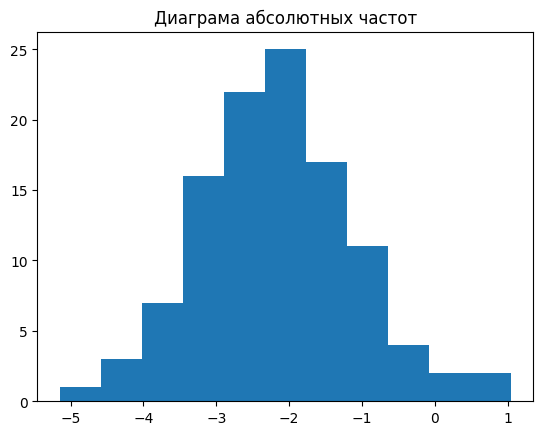

In [10]:
plt.title("Диаграма абсолютных частот")
plt.stairs(absoluty, bins , fill=True)

In [11]:
pdf = absoluty/(h*n)
pdf = list(pdf)
for i in range(0, len(pdf)):
    print(f'{i+1} интервал: {pdf[i]}')
pdf = np.array(pdf)
print(f'\nСумма относительных частот = {pdf.sum()}')

1 интервал: 0.01615743095504734
2 интервал: 0.04847229286514203
3 интервал: 0.11310201668533139
4 интервал: 0.25851889528075744
5 интервал: 0.3554634810110415
6 интервал: 0.4039357738761835
7 интервал: 0.2746763262358048
8 интервал: 0.17773174050552076
9 интервал: 0.06462972382018936
10 интервал: 0.03231486191009468
11 интервал: 0.03231486191009468

Сумма относительных частот = 1.7773174050552074


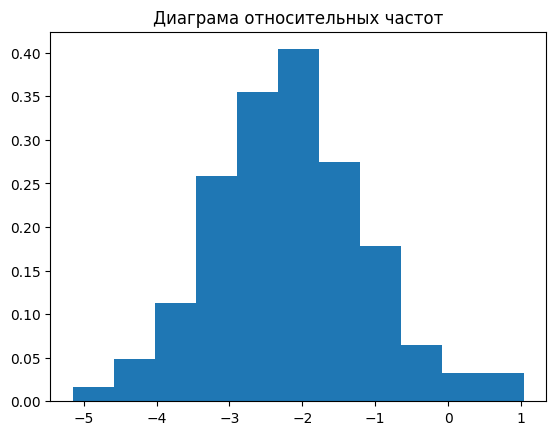

In [12]:
plt.title("Диаграма относительных частот")
plt.stairs(pdf, bins, fill=True)

Пункт 2

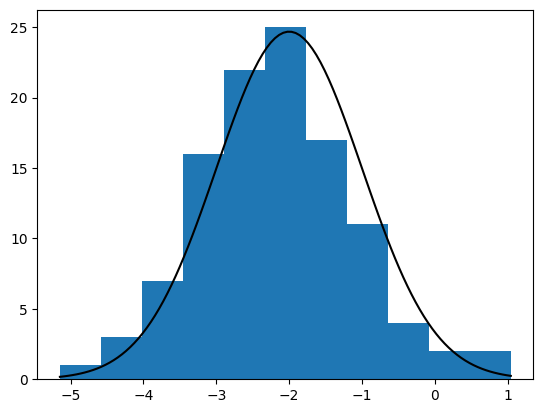

In [13]:
#s=pd.Series(data=dist)
num_bins= K_1
#sigma=1
#mu=a
n, bins, patches = plt.hist(dist, num_bins, density = 0)
#plt.stairs(absoluty, bins , fill=True)
#y = ((1 / (np.sqrt(2 * np.pi) * sigma)) *
#     np.exp(-0.5 * (1 / sigma * (bins - mu))**2))

#plt.plot(bins, y, color ='green') 
#s.hist(density=False)
#s.plot(kind='kde', figsize=(10,8))
#s.plot(kind='kde', figsize=(10,6))
n = 110
h = 0.5626457025378299
x = np.linspace(n_min, n_max, 110) 
y = sts.norm.pdf(x, a, sigma) * n * h
plt.plot(x, y, color = 'black')

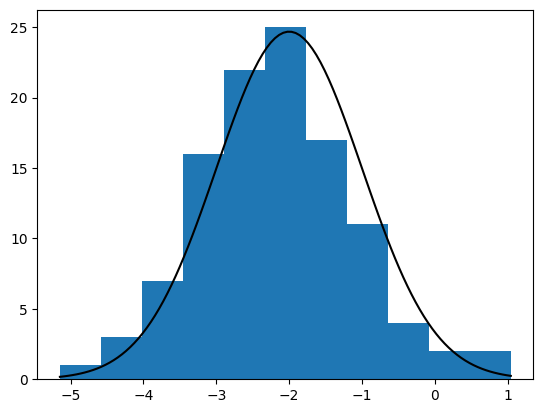

In [14]:
#s=pd.Series(data=dist)
num_bins= K_1
#sigma=1
#mu=a
#n, bins, patches = plt.hist(dist, num_bins, density = 0)
plt.stairs(absoluty, bins , fill=True)
#y = ((1 / (np.sqrt(2 * np.pi) * sigma)) *
#     np.exp(-0.5 * (1 / sigma * (bins - mu))**2))

#plt.plot(bins, y, color ='green') 
#s.hist(density=False)
#s.plot(kind='kde', figsize=(10,8))
#s.plot(kind='kde', figsize=(10,6))
n = 110
h = 0.5626457025378299
x = np.linspace(n_min, n_max, 110) 
y = sts.norm.pdf(x, a, sigma) * n * h
plt.plot(x, y, color = 'black')

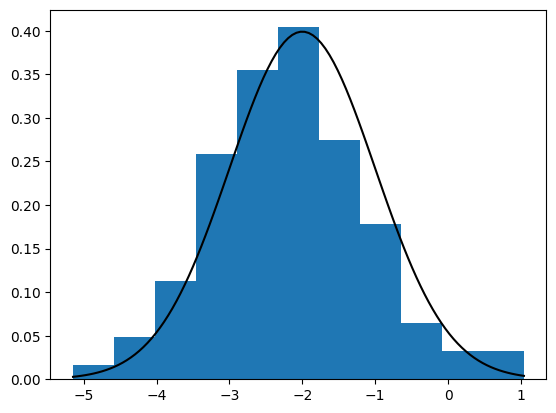

In [15]:
s=pd.Series(data=dist)
num_bins= K_1
sigma=1
mu=a
n, bins, patches = plt.hist(dist, num_bins, density = 1)
#y = ((1 / (np.sqrt(2 * np.pi) * sigma)) *
#     np.exp(-0.5 * (1 / sigma * (bins - mu))**2))

#plt.plot(bins, y, color ='green') # 
#s.hist(density=False)
#s.plot(kind='kde', figsize=(10,8))
#s.plot(kind='kde', figsize=(10,6))
x = np.linspace(n_min, n_max, 110) 
plt.plot(x, sts.norm.pdf(x, a, sigma), color = 'black') 

In [16]:
proof = 0 
for i in range(len(absoluty/n/h)):
    proof+=i*h
print("Сумма площадей под графиком: ", proof)

Сумма площадей под графиком:  30.94551363958064


[ 1  3  7 16 22 25 17 11  4  2  2]
[-5.14741652 -4.58477082 -4.02212512 -3.45947941 -2.89683371 -2.33418801
 -1.77154231 -1.2088966  -0.6462509  -0.0836052   0.4790405   1.04168621]
pdf = [0.00909091 0.02727273 0.06363636 0.14545455 0.2        0.22727273
 0.15454545 0.1        0.03636364 0.01818182 0.01818182]
cdf = [0.00909091 0.03636364 0.1        0.24545455 0.44545455 0.67272727
 0.82727273 0.92727273 0.96363636 0.98181818 1.        ]


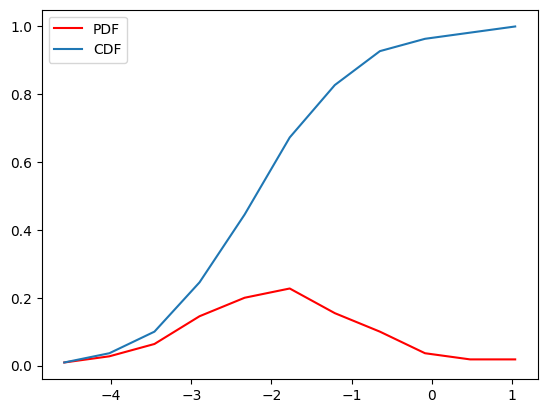

In [17]:
count, bins_count = np.histogram(dist, bins=K_1)
print(count)
print(bins_count)
#print(sum(count))
#left_bin =bins_count[0:10]
#right_bin =bins_count[1:11]
#print(left_bin)
#print(right_bin)
#shag=right_bin-left_bin
#print(shag)


pdf = count /sum(count)
print(f'pdf = {pdf}')
cdf = np.cumsum(pdf)
print(f'cdf = {cdf}')
# построение графиков в формате PDF и CDF
plt.plot(bins_count[1:], pdf, color="red", label="PDF")
plt.plot(bins_count[1:], cdf, label="CDF")
plt.legend()

Нижний предел: -4.711297980827786
Верхний предел: 0.3833445836989495
Число выбросов: 3
Выбросы: [ 0.87181939 -5.14741652  1.04168621]


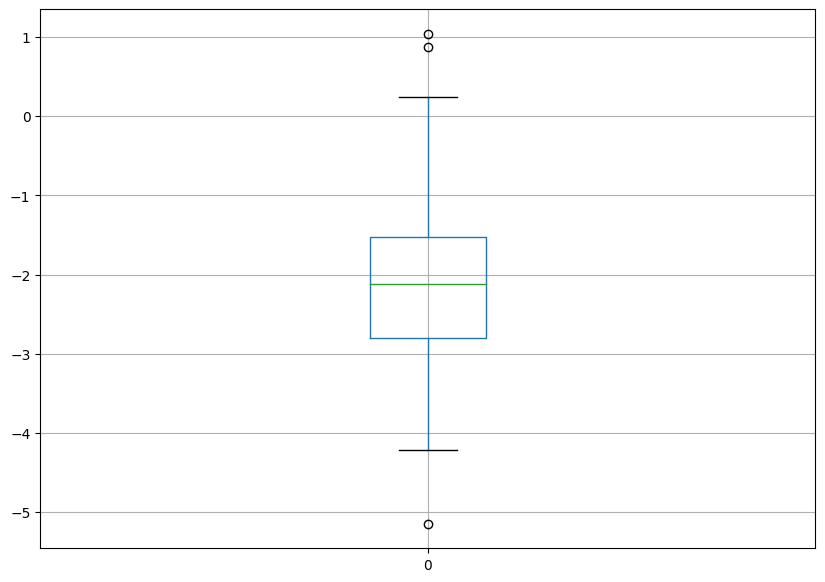

In [18]:
df = pd.DataFrame(data=dist)
df.boxplot(figsize = (10, 7))

lower_bound = q1 - 1.5 * IQR
print(f'Нижний предел: {lower_bound}')
upper_bound = q3 + 1.5 * IQR
print(f'Верхний предел: {upper_bound}')
out_liers = dist[(dist < lower_bound) | (dist > upper_bound)]
numberoutliers = len(out_liers)
print(f'Число выбросов: {numberoutliers}')
print(f'Выбросы: {out_liers}')

Пункт 3

In [131]:
print(f"Вероятность по таблице функций Лаппласа = {0.2881*2}")
print(f"Вероятность по python = {sts.norm().cdf(q*sigma)-sts.norm().cdf(-q*sigma)}")


m = 1
p = 0
for i in dist:
   if (i>a - q*sigma) and (i< a +q*sigma):
      p = p + 1
n = 110
print(p)
print(f'Оценка вероятноси: {p/n}')

Вероятность по таблице функций Лаппласа = 0.5762
Вероятность по python = 0.5762892028332067
63
Оценка вероятноси: 0.5727272727272728


In [21]:
n_50 = 5500
#np.random.seed(12)
dist_50 = np.random.normal(size = n_50, loc = a, scale = sigma)
m = 1
p = 0
for i in dist_50:
   if (i>a -q*sigma) and (i<a +q*sigma):
      p = p + 1
print(p)
print(f'Оценка вероятноси: {p/5500}')

3157
Оценка вероятноси: 0.574


Пункт 4

In [22]:
X = dist.sum()/len(dist)
print(f'среднее значение = {X}')

if len(dist_2) % 2 == 0:
  median_1 = dist_2[len(dist_2)//2]
  median_2 = dist_2[len(dist_2)//2 - 1]
  me = (median_1 + median_2)/2
else:
  me = dist_2[len(dist_2)//2]
print(f'медиана = {me}')

s2 = 0
for i in dist:
    s2 += (i-X)**2
s2 = s2/len(dist)
#print(f'Эмпирическая дисперсия = {s2}')
print(f'среднеквадратичное отклонение = {math.sqrt(s2)}')
print(f'дисперсия = {(s2)*len(dist)/(len(dist)-1)}')

x4 = 0
s3 = 0
s4 = 0
for i in dist:
    x4 += math.pow(i, 4)
    s3 += math.pow((i-X), 3)
    s4 += math.pow((i-X), 4)
x4 /= len(dist)
s3 /= len(dist)
s4 /= len(dist)
print(f'ассимметрия = {s3/math.pow(math.sqrt(s2), 3)}')
print(f'эксцесс = {s4/math.pow(s2, 2)-3}')

среднее значение = -2.1576385262052997
медиана = -2.121188728912257
среднеквадратичное отклонение = 1.061313600344083
дисперсия = 1.1367203799108734
ассимметрия = 0.29849251024968754
эксцесс = 0.5962802542328975


In [23]:
n_mean = dist.mean()
n_meadian = np.median(dist)
n_variacne = statistics.variance(dist)
n_dev = math.sqrt(n_variacne)
n_skewness = sts.skew(dist)
n_kurtosis = sts.kurtosis(dist)
print(f' среднее значение = {n_mean}, \n медиана = {me}, \n дисперсия = {n_variacne}, \n среднеквадратичное отклонение = {n_dev}, \n асимметрия = {n_skewness}, \n эксцесс = {n_kurtosis}')

 среднее значение = -2.1576385262052997, 
 медиана = -2.121188728912257, 
 дисперсия = 1.1367203799108736, 
 среднеквадратичное отклонение = 1.0661708962032652, 
 асимметрия = 0.29849251024968737, 
 эксцесс = 0.5962802542328958


После увеличения объёма выборки в 50 раз

In [24]:
n_mean = dist_50.mean()
n_meadian = np.median(dist_50)
n_variacne = statistics.variance(dist_50)
n_dev = math.sqrt(n_variacne)
n_skewness = sts.skew(dist_50)
n_kurtosis = sts.kurtosis(dist_50)
print(f' Матожидание = {n_mean}, \n медиана = {n_meadian}, \n дисперсия = {n_variacne}, \n среднеквадратичное отклонение = {n_dev}, \n асимметрия = {n_skewness}, \n эксцесс = {n_kurtosis}')

 Матожидание = -2.017558643211463, 
 медиана = -2.0282973194064886, 
 дисперсия = 0.9882811459573578, 
 среднеквадратичное отклонение = 0.9941233052078388, 
 асимметрия = 0.05094635819808112, 
 эксцесс = 0.0022553149192203747


Часть II

Пункт 1

In [9]:
from scipy.stats import chi2
import matplotlib.pyplot as plt
n = 110
df = 5
q = 0.8

In [10]:
djist = chi2.rvs(df, size = n)
djist

array([ 4.27071843,  7.92391466,  2.0726664 ,  2.27527297,  1.30721618,
       18.12808945,  3.83724637,  3.03598412,  1.9465006 ,  1.97987838,
        2.21960473,  2.88735154,  8.13588775,  2.21307262,  2.34997633,
        2.85502034,  3.36681698,  8.82704812,  7.32057639,  4.79335244,
        3.50738704, 10.55277943,  2.29225547,  0.9862758 ,  6.40630395,
        8.1922592 ,  2.82051125,  2.44114782,  2.83744073,  6.28410464,
        4.74862416,  4.26752232,  9.38531595,  0.93454072,  1.51960914,
        2.74948112,  3.81669756,  5.89365406,  3.44785637,  4.2803754 ,
        0.28341751, 10.22787132,  4.99393288,  4.02704032,  6.31156669,
        8.35350742,  1.63434482,  1.68694531,  8.06821603,  2.31769063,
        7.07929802, 10.09838887,  6.03074729,  8.92388483, 13.07958447,
        5.46667977,  4.93133134,  7.22482522,  3.76741179,  2.06121563,
        2.21086097,  2.64184579,  3.5289869 ,  4.13342895,  6.08073919,
        6.56634064,  3.77165179,  6.74865179,  7.74104673,  6.51

(array([0.05603914, 0.17932524, 0.13449393, 0.11207827, 0.06164305,
        0.0392274 , 0.02241565, 0.00560391, 0.        , 0.        ,
        0.00560391]),
 array([ 0.28341751,  1.90566042,  3.52790332,  5.15014622,  6.77238913,
         8.39463203, 10.01687493, 11.63911783, 13.26136074, 14.88360364,
        16.50584654, 18.12808945]),
 <BarContainer object of 11 artists>)

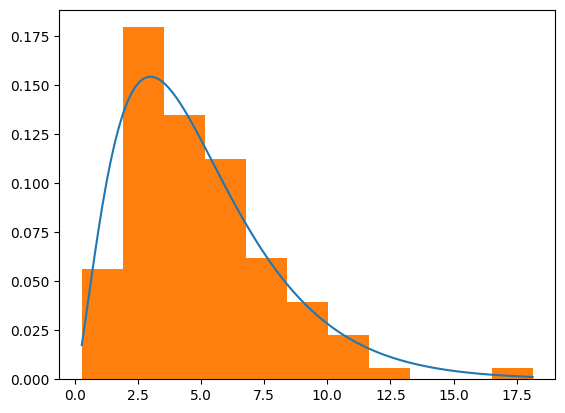

In [11]:
x = sorted(djist)
x = np.linspace(min(djist), max(djist), 110) 
#x = np.linspace(chi2.ppf(0.01, df), chi2.ppf(0.99, df), 110)
plt.plot(x, chi2.pdf(x, df= df))
plt.hist(djist, density=True, bins='auto')

In [12]:
count_chi, bins_count_chi = np.histogram(djist, bins='auto')
print(count_chi)
print(bins_count_chi)

[10 32 24 20 11  7  4  1  0  0  1]
[ 0.28341751  1.90566042  3.52790332  5.15014622  6.77238913  8.39463203
 10.01687493 11.63911783 13.26136074 14.88360364 16.50584654 18.12808945]


Первый квартиль: 2.6595762793043742
Второй квартиль: 4.275546915295312
Третий квартиль: 6.550244039761049
Межквартильный диапозон: 3.8906677604566746
Нижний предел: -3.176425361380638
Верхний предел: 12.386245680446061
Число выбросов: 2
Выбросы: 
18.12808944633986	
13.079584471917274	


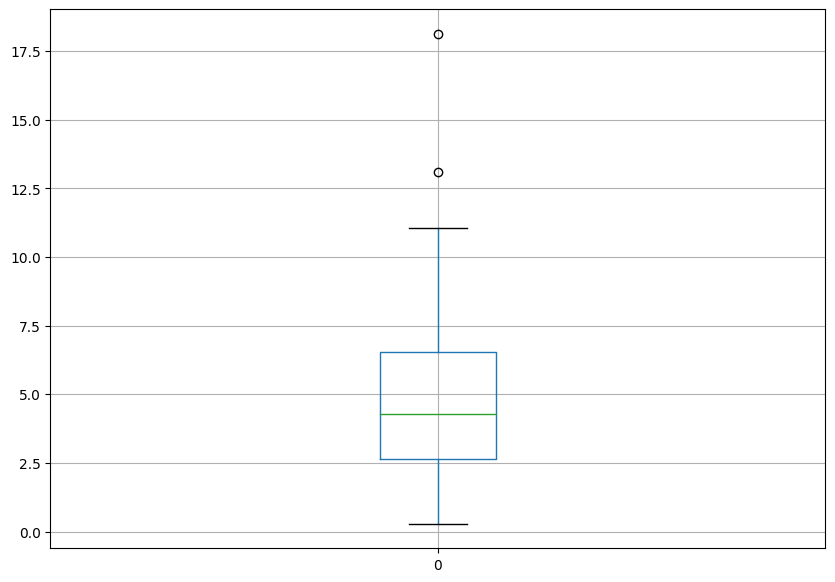

In [13]:
d = pd.DataFrame(data=djist)
d.boxplot(figsize = (10, 7))


q_1 = np.percentile(djist, 25)
print(f'Первый квартиль: {q_1}')
q_2 = np.percentile(djist, 50)
print(f'Второй квартиль: {q_2}')
q_3 = np.percentile(djist, 75)
print(f'Третий квартиль: {q_3}')
iqr = q_3 - q_1
print(f'Межквартильный диапозон: {iqr}')
lower_bound = q_1 - 1.5 * iqr
print(f'Нижний предел: {lower_bound}')
upper_bound = q_3 + 1.5 * iqr
print(f'Верхний предел: {upper_bound}')
outliers = djist[(djist < lower_bound) | (djist > upper_bound)]
number_outliers = len(outliers)
print(f'Число выбросов: {number_outliers}')
print('Выбросы: ')
for i in range(len(outliers)):
    print(f'{outliers[i]}\t')

In [14]:
sigma_chi_2 = np.sqrt(2*df)
print(sigma_chi_2)

prob = chi2.cdf(5 + q*sigma_chi_2, df = 5) - chi2.cdf(5 - q*sigma_chi_2, df = 5)
print(f"Вероятность по python = {prob}")
count = 0
for i in djist: 
    if np.abs(i - df) < q * sigma_chi_2:
         count = count + 1
#for i in djist:
#   if (i > 5 - 0.8 * sigma_chi_2) and (i < 5 + 0.8 * sigma_chi_2):
#      count = count + 1
relative = count / len(djist)
print(count)
print(f"Оценка вероятности = {relative}")

3.1622776601683795
Вероятность по python = 0.5968567525005419
65
Оценка вероятности = 0.5909090909090909


In [15]:
n_50 = 5500

djist_50 = chi2.rvs(df, size = n_50)
count_50 = 0
for i in djist_50:
   if (i>5 - q*sigma_chi_2) and (i< 5 +q*sigma_chi_2):
      count_50 = count_50 + 1
print(count_50)
relative_50 = count_50 / n_50
print(f"Оценка вероятности =  {relative_50}")

3276
Оценка вероятности =  0.5956363636363636


In [16]:
print(f'Матожидание Y = {np.mean(djist)}')
print(f'Медиана Y = {np.median(djist)}')
print(f'Дисперсия Y = {statistics.variance(djist)}')
print(f'Стандартное отклонение Y = {math.sqrt(statistics.variance(djist))}')
print(f'Kоэффициент ассиметрии Y = {sts.skew(djist, bias= False)}')
print(f'Эксцесс Y = {sts.kurtosis(djist, bias= False)}')

Матожидание Y = 4.929271232408454
Медиана Y = 4.275546915295312
Дисперсия Y = 8.625741094478164
Стандартное отклонение Y = 2.936961200710381
Kоэффициент ассиметрии Y = 1.212141559215821
Эксцесс Y = 2.732123704669146


In [17]:
print(f'Матожидание Y = {np.mean(djist_50)}')
print(f'Медиана Y = {np.median(djist_50)}')
print(f'Дисперсия Y = {statistics.variance(djist_50)}')
print(f'Стандартное отклонение Y = {math.sqrt(statistics.variance(djist_50))}')
print(f'Kоэффициент ассиметрии Y = {sts.skew(djist_50)}')
print(f'Эксцесс Y = {sts.kurtosis(djist_50)}')

Матожидание Y = 4.98043208783799
Медиана Y = 4.342240843177747
Дисперсия Y = 9.809657937323882
Стандартное отклонение Y = 3.1320373460934148
Kоэффициент ассиметрии Y = 1.2251419639222019
Эксцесс Y = 2.0613621266736635
